In [1]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

In [2]:
rabbit = cv2.imread('data/crol.jpg')
rabbit.shape

(513, 563, 3)

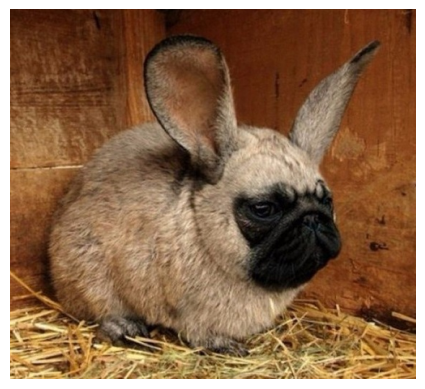

In [3]:
image_rgb = cv2.cvtColor(rabbit, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.axis('off')
plt.show()

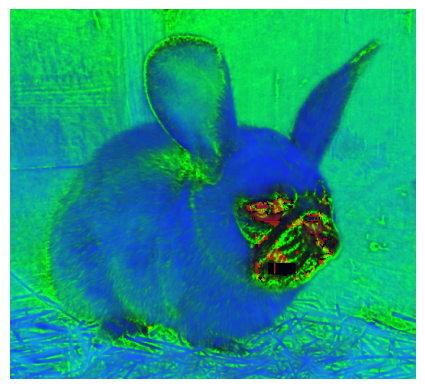

In [4]:
image_hsv = cv2.cvtColor(rabbit, cv2.COLOR_BGR2HSV)

plt.imshow(image_hsv)
plt.axis('off')
plt.show()

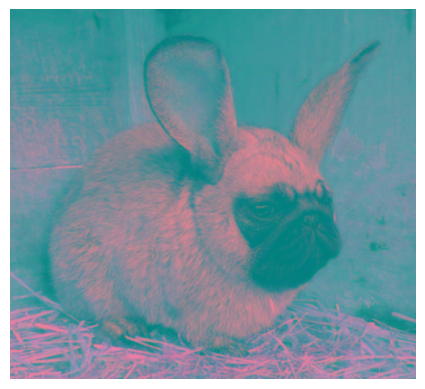

In [5]:
image_lab = cv2.cvtColor(rabbit, cv2.COLOR_BGR2Lab)

plt.imshow(image_lab)
plt.axis('off')
plt.show()

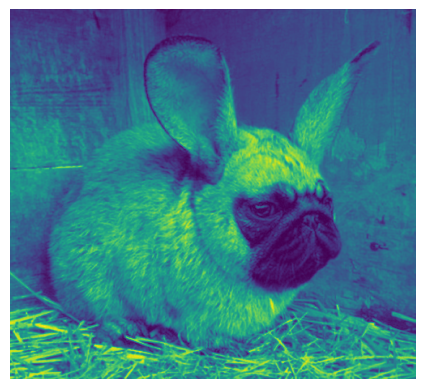

In [6]:
image_gray = cv2.cvtColor(rabbit, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray)
plt.axis('off')
plt.show()

возможные преобразования  
cv2.COLOR_BGR2GRAY: Преобразование изображения из цветового пространства BGR в оттенки серого.  
cv2.COLOR_BGR2RGB: Преобразование изображения из цветового пространства BGR в RGB.  
cv2.COLOR_BGR2Lab: Преобразование изображения из цветового пространства BGR в цветовое пространство CIELAB.  
cv2.COLOR_BGR2YUV: Преобразование изображения из цветового пространства BGR в цветовое пространство YUV.  
cv2.COLOR_BGR2HLS: Преобразование изображения из цветового пространства BGR в цветовое пространство HLS.  

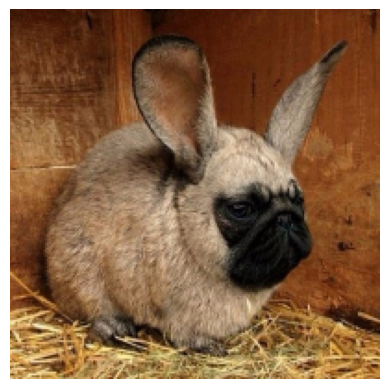

In [7]:
resized_image = cv2.resize(image_rgb, (200, 200))

plt.imshow(resized_image)
plt.axis('off')
plt.show()

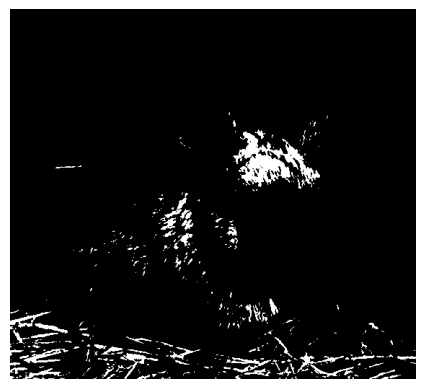

In [8]:
_, thresholded = cv2.threshold(image_gray,180, 255, cv2.THRESH_BINARY)

plt.imshow(thresholded, cmap='gray')
plt.axis('off')
plt.show()

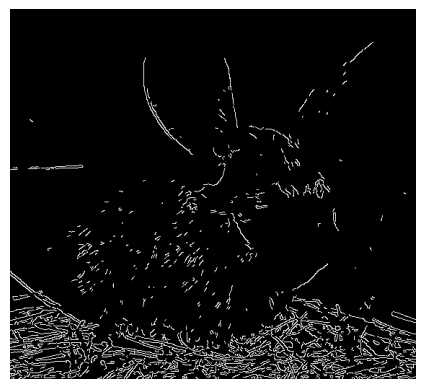

In [9]:
edges = cv2.Canny(image_gray, 180, 250)

plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.show()

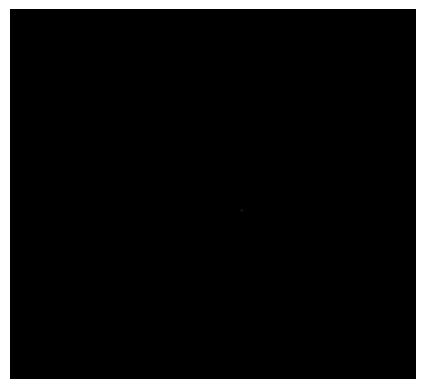

In [10]:
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])

mask = cv2.inRange(image_hsv, lower_green, upper_green)

res_image = cv2.bitwise_and(image_rgb, image_rgb, mask=mask)
plt.imshow(res_image)
plt.axis('off')
plt.show()

In [11]:
k = 15   # число кластеров (можно изменить по желанию)

pixel_values = np.float32(image_rgb.reshape((-1, 3)))

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2) # Критерии завершения (тип, макс. число итераций, требуемая точность)

_, labels, centers = cv2.kmeans(pixel_values, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)

segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(image_rgb.shape)

In [12]:
segmented_image.max(), segmented_image.min(), image_rgb.max(), image_rgb.min()

(227, 8, 255, 0)

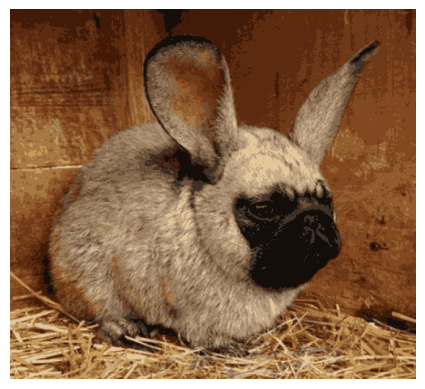

In [13]:
plt.imshow(segmented_image)
plt.axis('off')
plt.show()

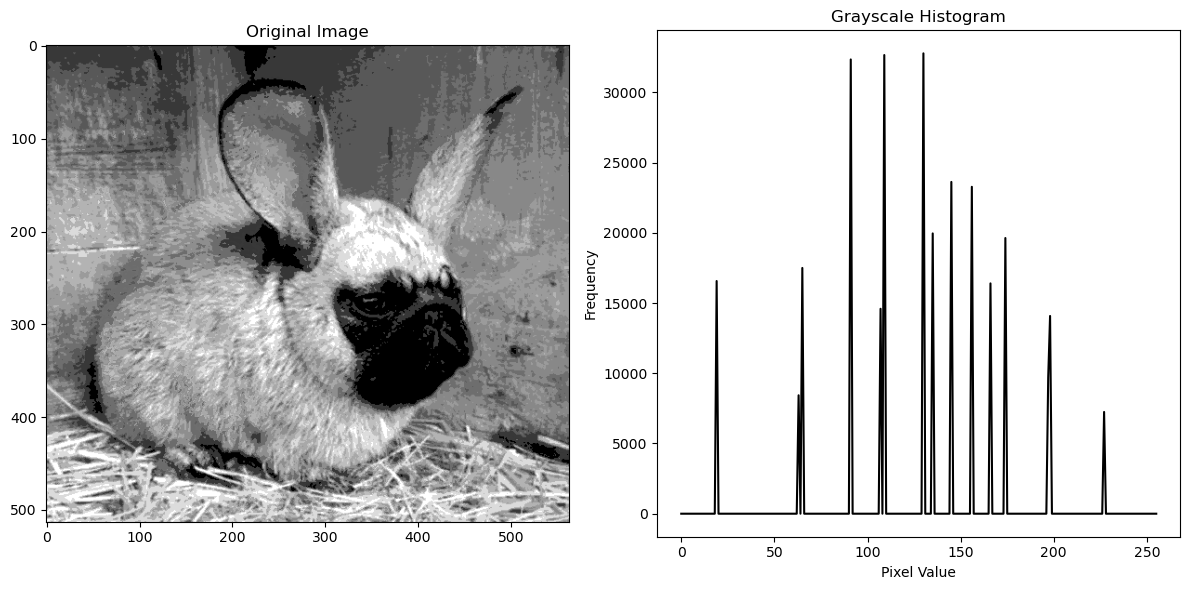

In [14]:
image = cv2.imread('img_0.jpg', cv2.IMREAD_GRAYSCALE)

# Вычисление гистограммы
hist = cv2.calcHist([segmented_image[:,:,0]], [0], None, [256], [0,256])

# Отображение изображения и его гистограммы
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(segmented_image[:,:,0], cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.plot(hist, color='black')
plt.title('Grayscale Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from keras_vggface.vggface import VGGFace
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras_vggface.utils import preprocess_input

In [16]:
vggface = VGGFace(model='resnet50')

165439116/165439116 [==============================] - 6s 0us/step


In [17]:
from pathlib import Path

data_folder = Path("data/UTKFace/")
filenames = list(map(lambda x: x.name, data_folder.glob('*.jpg')))
print(len(filenames))
print(filenames[:3])

23708
['100_0_0_20170112213500903.jpg.chip.jpg', '100_0_0_20170112215240346.jpg.chip.jpg', '100_1_0_20170110183726390.jpg.chip.jpg']


In [18]:
import pandas as pd

np.random.seed(10)
np.random.shuffle(filenames)
gender_mapping = {0: 'Male', 1: 'Female'}
race_mapping = dict(list(enumerate(('White', 'Black', 'Asian', 'Indian', 'Others'))))
age_labels, gender_labels, race_labels, correct_filenames = [], [], [], []

for filename in filenames:
    if len(filename.split('_')) != 4:
        print(f"Bad filename {filename}")
        continue

    age, gender, race, _ = filename.split('_')
    correct_filenames.append(filename)
    age_labels.append(age)
    gender_labels.append(gender)
    race_labels.append(race)

age_labels = np.array(age_labels, dtype=np.float32)
max_age = age_labels.max()
data = {"img_name": correct_filenames,
        "age": age_labels / max_age, # нормализация возраста от 0 до 1
        "race": race_labels,
        "gender": gender_labels}
df = pd.DataFrame(data)
df.head()

Bad filename 61_1_20170109150557335.jpg.chip.jpg
Bad filename 61_1_20170109142408075.jpg.chip.jpg
Bad filename 39_1_20170116174525125.jpg.chip.jpg


,img_name,age,race,gender
0,23_1_2_20170116172910708.jpg.chip.jpg,0.198276,2,1
1,28_0_1_20170113150719161.jpg.chip.jpg,0.241379,1,0
2,26_1_0_20170116234741431.jpg.chip.jpg,0.224138,0,1
3,37_0_3_20170119202516470.jpg.chip.jpg,0.318966,3,0
4,60_0_0_20170109013457906.jpg.chip.jpg,0.517241,0,0


In [19]:
from sklearn.model_selection import train_test_split


df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

print(f"Размер тренировочной выборки: {len(df_train)}")
print(f"Размер тестовой выборки: {len(df_test)}")

Размер тренировочной выборки: 18964
Размер тестовой выборки: 4741


In [20]:
def decode_labels(race_id, gender_id, age):
    return race_mapping[int(race_id)], gender_mapping[int(gender_id)], int(age*max_age)

def show_face(image, race_id, gender_id, age):
    plt.imshow(image)
    race, gender, age = decode_labels(race_id, gender_id, age)
    plt.title(f"Gender: {gender}, Race: {race}, Age: {age}")

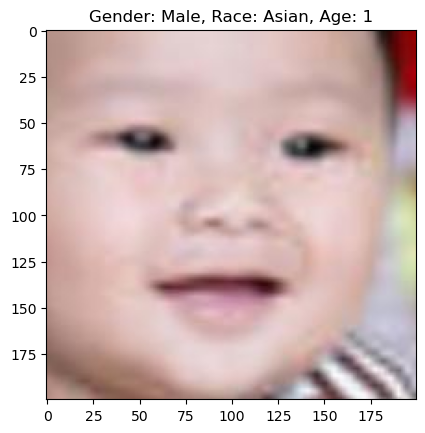

In [21]:
row = df_train.iloc[np.random.randint(len(df_train))]
img = plt.imread(str(data_folder/row["img_name"]))
show_face(img, row["race"], row["gender"], row["age"])

In [22]:


def preprocess_input_facenet(image_):
    preprocessed = preprocess_input(image_, version=2)
    return preprocessed

image_gen = ImageDataGenerator(preprocessing_function=preprocess_input_facenet)

In [23]:
BATCH_SIZE = 128
IMAGE_SIZE = 224

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input_facenet, horizontal_flip=True)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input_facenet)

train_df = df_train.copy()
train_df['gender'] = train_df['gender'].astype(str) 
val_df = df_test.copy()
val_df['gender'] = val_df['gender'].astype(str) 

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=str(data_folder),
    x_col="img_name",
    y_col="gender",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True 
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=str(data_folder),
    x_col="img_name",
    y_col="gender",
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False 
)

Found 18964 validated image filenames belonging to 2 classes.
Found 4741 validated image filenames belonging to 2 classes.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Male


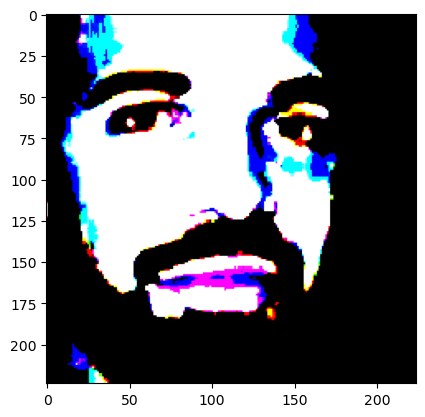

In [24]:

sample_images, sample_labels = next(val_generator)

plt.imshow(sample_images[100])
print(gender_mapping[int(sample_labels[100])])

Male


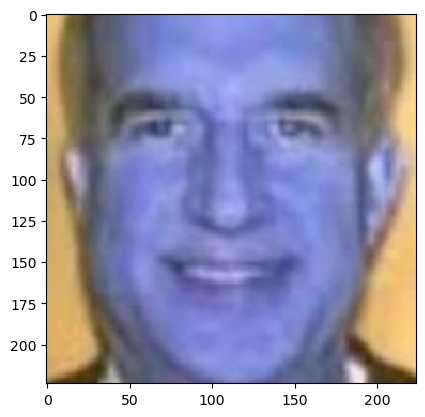

In [25]:
VGGFACE2_MEAN = [91.4953, 103.8827, 131.0912]

def deprocess_image(vggface_image):
    image = np.copy(vggface_image)
    
    # Добавляем средние значения RGB
    image[..., 0] += VGGFACE2_MEAN[0]
    image[..., 1] += VGGFACE2_MEAN[1]
    image[..., 2] += VGGFACE2_MEAN[2]
    
    # Обрезаем значения к диапазону [0, 255]
    image = np.clip(image, 0, 255).astype(np.uint8)
    
    return image


sample_images, sample_labels = next(val_generator)
plt.imshow(deprocess_image(sample_images[5]))
print(gender_mapping[int(sample_labels[5])])

In [27]:

base_model = tf.keras.Model([vggface.input], vggface.get_layer("flatten").output) # убираем последний слой модели
base_model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv1/7x7_s2 (Conv2D)          (None, 112, 112, 64  9408        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv1/7x7_s2/bn (BatchNormaliz  (None, 112, 112, 64  256        ['conv1/7x7_s2[0][0]']           
 ation)                         )                                                             

                                                                                                  
 conv2_3_1x1_increase (Conv2D)  (None, 55, 55, 256)  16384       ['activation_8[0][0]']           
                                                                                                  
 conv2_3_1x1_increase/bn (Batch  (None, 55, 55, 256)  1024       ['conv2_3_1x1_increase[0][0]']   
 Normalization)                                                                                   
                                                                                                  
 add_2 (Add)                    (None, 55, 55, 256)  0           ['conv2_3_1x1_increase/bn[0][0]',
                                                                  'activation_6[0][0]']           
                                                                                                  
 activation_9 (Activation)      (None, 55, 55, 256)  0           ['add_2[0][0]']                  
          

 add_5 (Add)                    (None, 28, 28, 512)  0           ['conv3_3_1x1_increase/bn[0][0]',
                                                                  'activation_15[0][0]']          
                                                                                                  
 activation_18 (Activation)     (None, 28, 28, 512)  0           ['add_5[0][0]']                  
                                                                                                  
 conv3_4_1x1_reduce (Conv2D)    (None, 28, 28, 128)  65536       ['activation_18[0][0]']          
                                                                                                  
 conv3_4_1x1_reduce/bn (BatchNo  (None, 28, 28, 128)  512        ['conv3_4_1x1_reduce[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 activatio

                                                                                                  
 activation_27 (Activation)     (None, 14, 14, 1024  0           ['add_8[0][0]']                  
                                )                                                                 
                                                                                                  
 conv4_3_1x1_reduce (Conv2D)    (None, 14, 14, 256)  262144      ['activation_27[0][0]']          
                                                                                                  
 conv4_3_1x1_reduce/bn (BatchNo  (None, 14, 14, 256)  1024       ['conv4_3_1x1_reduce[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 activation_28 (Activation)     (None, 14, 14, 256)  0           ['conv4_3_1x1_reduce/bn[0][0]']  
          

                                                                                                  
 conv4_6_1x1_reduce/bn (BatchNo  (None, 14, 14, 256)  1024       ['conv4_6_1x1_reduce[0][0]']     
 rmalization)                                                                                     
                                                                                                  
 activation_37 (Activation)     (None, 14, 14, 256)  0           ['conv4_6_1x1_reduce/bn[0][0]']  
                                                                                                  
 conv4_6_3x3 (Conv2D)           (None, 14, 14, 256)  589824      ['activation_37[0][0]']          
                                                                                                  
 conv4_6_3x3/bn (BatchNormaliza  (None, 14, 14, 256)  1024       ['conv4_6_3x3[0][0]']            
 tion)                                                                                            
          

 activation_46 (Activation)     (None, 7, 7, 512)    0           ['conv5_3_1x1_reduce/bn[0][0]']  
                                                                                                  
 conv5_3_3x3 (Conv2D)           (None, 7, 7, 512)    2359296     ['activation_46[0][0]']          
                                                                                                  
 conv5_3_3x3/bn (BatchNormaliza  (None, 7, 7, 512)   2048        ['conv5_3_3x3[0][0]']            
 tion)                                                                                            
                                                                                                  
 activation_47 (Activation)     (None, 7, 7, 512)    0           ['conv5_3_3x3/bn[0][0]']         
                                                                                                  
 conv5_3_1x1_increase (Conv2D)  (None, 7, 7, 2048)   1048576     ['activation_47[0][0]']          
          

In [28]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Model

for layer in base_model.layers:
    layer.trainable = False
    
x = base_model.output
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [29]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [30]:
EPOCHS = 5

history = model.fit(train_generator, steps_per_epoch=train_generator.samples // BATCH_SIZE, validation_data=val_generator,
                    validation_steps=val_generator.samples // BATCH_SIZE, epochs=EPOCHS)

Epoch 1/5
 21/148 [===>..........................] - ETA: 6:15 - loss: 0.8904 - accuracy: 0.7481

KeyboardInterrupt: 